# Cohorts: is retention stable across signup months?

Business question: do retention patterns vary by signup cohort, and which windows are mature enough to compare?

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
ARTIFACTS = ROOT / "artifacts"
with (ARTIFACTS / "results.json").open() as handle:
    results = json.load(handle)

def table(name, n=8):
    frame = pd.read_csv(ARTIFACTS / "tables" / name)
    display(frame.head(n))
    return frame

def figure(name):
    png = ARTIFACTS / "figures" / f"{name}.png"
    svg = ARTIFACTS / "figures" / f"{name}.svg"
    assert png.exists() and svg.exists(), f"missing paired figure outputs for {name}"
    assert "<svg" in svg.read_text(encoding="utf-8")[:1000]
    display(Image(filename=str(png), width=640))
    return png, svg


,cohort_month,cohort_size,retention,horizon_days,window_start_day,window_end_day,analysis_end
0,2025-01,11653,0.263451,7,7,13,2026-01-25
1,2025-02,10348,0.293487,7,7,13,2026-01-25
2,2025-03,11489,0.324571,7,7,13,2026-01-25
3,2025-04,11265,0.292499,7,7,13,2026-01-25
4,2025-05,11343,0.318522,7,7,13,2026-01-25
5,2025-06,10894,0.268864,7,7,13,2026-01-25
6,2025-07,11502,0.322031,7,7,13,2026-01-25
7,2025-08,11542,0.292584,7,7,13,2026-01-25
8,2025-09,9964,0.300883,7,7,13,2026-01-25
9,2025-01,11653,0.189908,30,30,36,2026-01-25


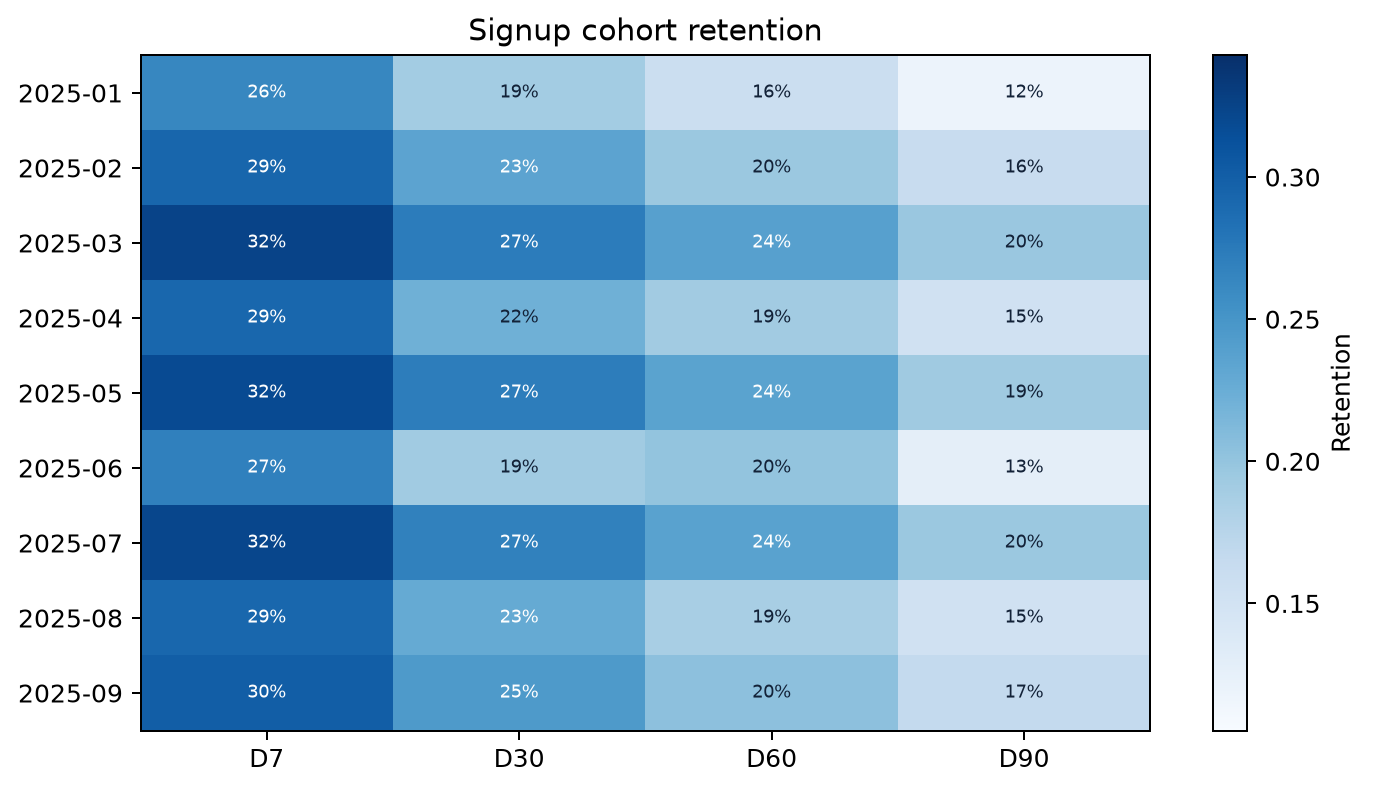

{'d7': 'D7-13', 'd30': 'D30-36', 'd60': 'D60-66', 'd90': 'D90-96'}


In [2]:
cohorts = table('retention_cohorts.csv', n=12)
figure('cohort_retention')
print(results['journey']['retention_windows'])

In [3]:
mature = cohorts.dropna(subset=['retention']).copy()
latest = mature.sort_values(['horizon_days', 'cohort_month']).groupby('horizon_days').tail(1)
print('Evidence: maturity is encoded by horizon windows and analysis_end in the generated table.')
display(latest[['cohort_month', 'horizon_days', 'retention', 'cohort_size']])
print('Decision: use mature cohort comparisons to choose retention follow-up; treat recent cohorts as not-yet-observable rather than inactive.')

Evidence: maturity is encoded by horizon windows and analysis_end in the generated table.


,cohort_month,horizon_days,retention,cohort_size
8,2025-09,7,0.300883,9964
17,2025-09,30,0.245283,9964
26,2025-09,60,0.204436,9964
35,2025-09,90,0.165596,9964


Decision: use mature cohort comparisons to choose retention follow-up; treat recent cohorts as not-yet-observable rather than inactive.


**Uncertainty and scope.** Uncertainty: cohort retention is observational and synthetic; seasonality, composition, and incomplete windows can confound comparisons.

**Decision framing.** Treat the generated artifacts as an auditable working read: inspect the source table, check assumptions, and validate the proposed action with an appropriate follow-up measurement.